In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

print("Python data analysis environment is ready.")

Python data analysis environment is ready.


In [6]:
DB_USER = "dataanalyst"
DB_PASSWORD = "2326"
DB_HOST = "127.0.0.1"
DB_PORT = "5432"
DB_NAME = "data_analysis"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("PostgreSQL engine created.")

PostgreSQL engine created.


In [7]:
with engine.connect() as connection:
    result = connection.execute(text("SELECT current_database(), version();"))
    row = result.fetchone()

print("Database:", row[0])
print("PostgreSQL:", row[1])

Database: data_analysis
PostgreSQL: PostgreSQL 16.15 (Ubuntu 16.15-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0, 64-bit


In [8]:
query = """
SELECT COUNT(*) AS total_rows
FROM austin_fc_sales_history;
"""

df_count = pd.read_sql(query, engine)

df_count

,total_rows
0,5326581


In [9]:
sample_query = """
SELECT *
FROM austin_fc_sales_history
LIMIT 100000;
"""

df = pd.read_sql(sample_query, engine)

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 100000
Columns: 27


In [10]:
df.head()

,primary_ticket_id,subscription_instance_id,sales_item_id,product_item_id,transaction_id,product_id,internal_account_id,sales_rep,transaction_date,last_touched_at,...,price_type,price_type_group,total_payment,total_plan_amount,section,row,seat,product_description,application_channel,is_hospitality
0,337a7055-8cbf-e911-a9ce-b4d295c803b4,2a7a7055-8cbf-e911-a9ce-b4d295c803b4,8fa24f5c-8cbf-e911-a9ce-b4d295c803b4,337a7055-8cbf-e911-a9ce-b4d295c803b4,a9b3cd37-8cbf-e911-a9ce-b4d295c803b4,e7768212-79bf-e911-a9ce-b4d295c803b4,ae84147ac51f28bfb7426fb2a4a857dcf4058400c7547d...,NaN,2019-08-15 18:42:04.997,2026-04-13 08:43:33.184542+00:00,...,Adult,Adult,50.0,0.0,Loft 01,1,2,TEST Match 2,bSRO,False
1,327a7055-8cbf-e911-a9ce-b4d295c803b4,2a7a7055-8cbf-e911-a9ce-b4d295c803b4,8ea24f5c-8cbf-e911-a9ce-b4d295c803b4,327a7055-8cbf-e911-a9ce-b4d295c803b4,a9b3cd37-8cbf-e911-a9ce-b4d295c803b4,dbeb39ba-78bf-e911-a9ce-b4d295c803b4,ae84147ac51f28bfb7426fb2a4a857dcf4058400c7547d...,NaN,2019-08-15 18:42:04.997,2026-04-13 08:43:33.184542+00:00,...,Adult,Adult,50.0,0.0,Loft 01,1,2,TEST Match 1,bSRO,False
2,347a7055-8cbf-e911-a9ce-b4d295c803b4,2a7a7055-8cbf-e911-a9ce-b4d295c803b4,90a24f5c-8cbf-e911-a9ce-b4d295c803b4,347a7055-8cbf-e911-a9ce-b4d295c803b4,a9b3cd37-8cbf-e911-a9ce-b4d295c803b4,467e7422-79bf-e911-a9ce-b4d295c803b4,ae84147ac51f28bfb7426fb2a4a857dcf4058400c7547d...,NaN,2019-08-15 18:42:04.997,2026-04-13 08:43:33.184542+00:00,...,Adult,Adult,50.0,0.0,Loft 01,1,2,TEST Match 3,bSRO,False
3,377a7055-8cbf-e911-a9ce-b4d295c803b4,2b7a7055-8cbf-e911-a9ce-b4d295c803b4,94a24f5c-8cbf-e911-a9ce-b4d295c803b4,377a7055-8cbf-e911-a9ce-b4d295c803b4,a9b3cd37-8cbf-e911-a9ce-b4d295c803b4,467e7422-79bf-e911-a9ce-b4d295c803b4,ae84147ac51f28bfb7426fb2a4a857dcf4058400c7547d...,NaN,2019-08-15 18:42:04.997,2026-04-13 08:43:33.184542+00:00,...,Adult,Adult,50.0,0.0,Loft 01,1,1,TEST Match 3,bSRO,False
4,357a7055-8cbf-e911-a9ce-b4d295c803b4,2b7a7055-8cbf-e911-a9ce-b4d295c803b4,92a24f5c-8cbf-e911-a9ce-b4d295c803b4,357a7055-8cbf-e911-a9ce-b4d295c803b4,a9b3cd37-8cbf-e911-a9ce-b4d295c803b4,dbeb39ba-78bf-e911-a9ce-b4d295c803b4,ae84147ac51f28bfb7426fb2a4a857dcf4058400c7547d...,NaN,2019-08-15 18:42:04.997,2026-04-13 08:43:33.184542+00:00,...,Adult,Adult,50.0,0.0,Loft 01,1,1,TEST Match 1,bSRO,False


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   primary_ticket_id         95101 non-null   str                
 1   subscription_instance_id  98058 non-null   str                
 2   sales_item_id             100000 non-null  str                
 3   product_item_id           100000 non-null  str                
 4   transaction_id            100000 non-null  str                
 5   product_id                100000 non-null  str                
 6   internal_account_id       99999 non-null   str                
 7   sales_rep                 81267 non-null   str                
 8   transaction_date          100000 non-null  datetime64[us]     
 9   last_touched_at           100000 non-null  datetime64[us, UTC]
 10  item_type                 100000 non-null  str                
 11  product_type

In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
primary_ticket_id,95101,95101,337a7055-8cbf-e911-a9ce-b4d295c803b4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_instance_id,98058,4996,cece182c-19ff-e911-a9ce-0a593f791696,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_item_id,100000,100000,8fa24f5c-8cbf-e911-a9ce-b4d295c803b4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_item_id,100000,100000,337a7055-8cbf-e911-a9ce-b4d295c803b4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_id,100000,3607,d28877de-f506-ea11-a9ce-0a593f791696,380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,100000,48,c9278231-37e1-48c1-a9f0-f48bf3e52c4e,4521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internal_account_id,99999,3020,92ea7dd2ed7b9bd5b80cecc4f22f97e662c81cfed76aa7...,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_rep,81267,10,aaa43811-d1ee-e911-a9ce-0a593f791696,15980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_date,100000,NaN,NaN,NaN,2020-03-24 20:20:29.943008,2019-08-15 18:42:04.997000,2020-01-24 00:00:07.927000,2020-03-31 14:35:52.473000,2020-05-08 03:00:11.743000,2021-06-09 21:11:12.377000,NaN
last_touched_at,100000,NaN,NaN,NaN,2026-04-20 22:19:27.352068+00:00,2026-04-13 08:43:33.184542+00:00,2026-04-13 08:43:33.184542+00:00,2026-04-13 08:43:33.184542+00:00,2026-04-13 08:43:33.184542+00:00,2026-09-18 14:32:39.422435+00:00,NaN


In [13]:
df.isna().sum()

primary_ticket_id            4899
subscription_instance_id     1942
sales_item_id                   0
product_item_id                 0
transaction_id                  0
product_id                      0
internal_account_id             1
sales_rep                   18733
transaction_date                0
last_touched_at                 0
item_type                       0
product_type                    0
sale_type                       0
transfer_status             60369
resale_status               91152
sales_details               95101
price_level                     0
price_type                      0
price_type_group                4
total_payment                   0
total_plan_amount               0
section                      1610
row                          1610
seat                         1610
product_description             0
application_channel             0
is_hospitality                  0
dtype: int64

In [14]:
df["total_payment"].describe()

count    100000.000000
mean        331.729208
std         983.034440
min           0.000000
25%          80.000000
50%         100.000000
75%         264.000000
max       13262.000000
Name: total_payment, dtype: float64

In [15]:
print("Total payment:", df["total_payment"].sum())
print("Average payment:", df["total_payment"].mean())
print("Median payment:", df["total_payment"].median())
print("Maximum payment:", df["total_payment"].max())

Total payment: 33172920.819999997
Average payment: 331.72920819999996
Median payment: 100.0
Maximum payment: 13262.0


In [16]:
product_summary = (
    df.groupby("product_type")
      .agg(
          records=("product_type", "size"),
          revenue=("total_payment", "sum"),
          average_payment=("total_payment", "mean")
      )
      .sort_values("revenue", ascending=False)
)

product_summary

,records,revenue,average_payment
product_type,,,
Ticket,95101,16638256.82,174.953542
Subscription,4899,16534664.00,3375.110022


In [17]:
channel_summary = (
    df.groupby("application_channel")
      .agg(
          records=("application_channel", "size"),
          revenue=("total_payment", "sum"),
          average_payment=("total_payment", "mean")
      )
      .sort_values("revenue", ascending=False)
)

channel_summary

,records,revenue,average_payment
application_channel,,,
bSRO,81274,31575353.82,388.504981
eSRO,17241,1597567.00,92.660925
Internal,1485,0.00,0.000000


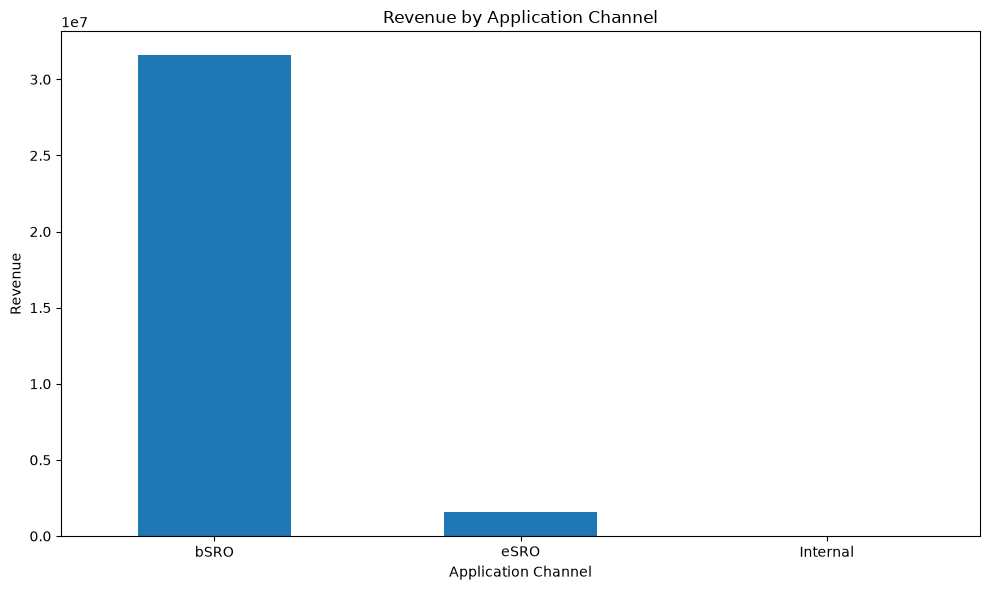

In [18]:
channel_summary["revenue"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Revenue by Application Channel")
plt.xlabel("Application Channel")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [20]:
df["transaction_month"] = df["transaction_date"].dt.to_period("M")

In [21]:
monthly_sales = (
    df.groupby("transaction_month")
      .agg(
          transactions=("transaction_id", "count"),
          revenue=("total_payment", "sum")
      )
)

monthly_sales.head()

,transactions,revenue
transaction_month,,
2019-08,18,900.00
2019-10,26,1850.00
2019-11,10943,8934594.88
2019-12,7327,4544212.00
2020-01,8867,3442968.13


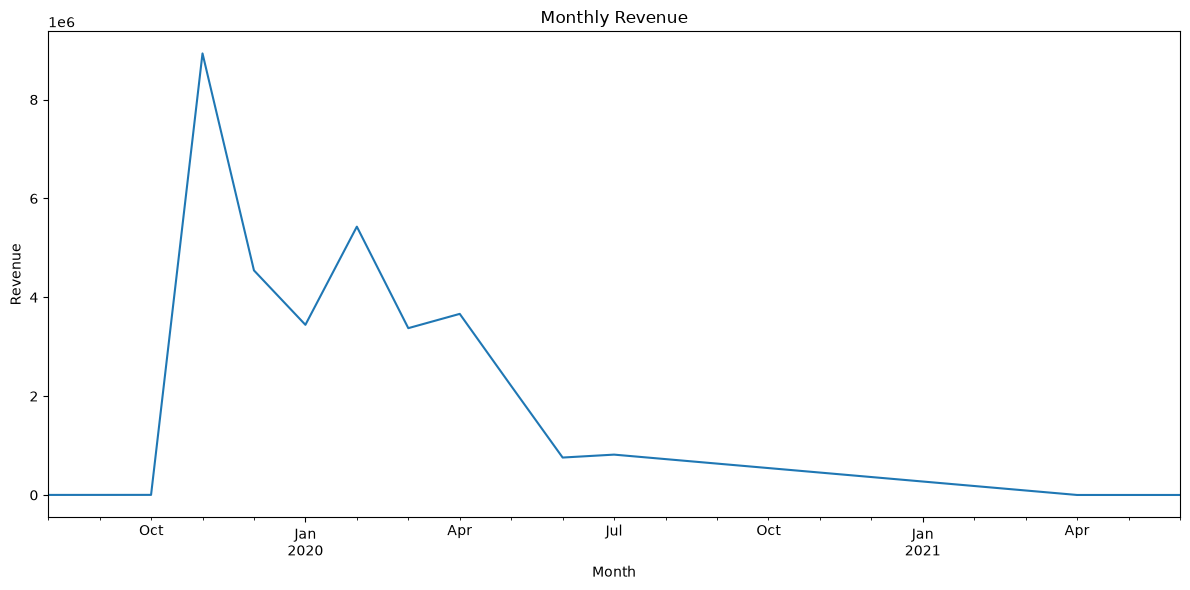

In [22]:
monthly_sales["revenue"].plot(
    figsize=(12, 6)
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()